# Pan-Cancer Multi-Initialisation Co-occurrence Analysis

Analyses the stability of the Tied Bayesian Mallows clustering across multiple random initialisations.  
Runs are loaded from `runs_multi_init/` (K=30, mu=0.0001, 20 initialisations).

The analysis covers:
1. Building a sample-level co-occurrence matrix from MAP assignments across runs.
2. Visualising the co-occurrence as a reordered heatmap.
3. Deriving a dendrogram from the co-occurrence distance.
4. Fitting spectral clustering for a range of K and evaluating via silhouette scores.

## 1. Configuration & Data Loading

In [1]:
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score

# ── Configuration ─────────────────────────────────────────────────────────────
RUN_DIR   = "runs_multi_init/K30"
CT_FILE   = "pan_cancer/cancertype.csv"
K_RANGE   = range(2, 16)          # K values to evaluate with spectral clustering
LINKAGE_METHOD = "average"        # linkage method for the dendrogram
# ──────────────────────────────────────────────────────────────────────────────

npz_files = sorted(glob.glob(f"{RUN_DIR}/*.npz"))
print(f"Found {len(npz_files)} initialisation runs:")
for p in npz_files:
    print(f"  {p}")

z_maps = []   # list of (N,) arrays, one per initialisation
for path in npz_files:
    npz = np.load(path, allow_pickle=True)
    z_maps.append(npz["z_map"])

N = z_maps[0].shape[0]
n_runs = len(z_maps)
print(f"\nN = {N} samples, {n_runs} initialisations loaded")

ct = pd.read_csv(CT_FILE, index_col=0)
cancer_types = ct["cancertype"].values
print(f"Cancer types: {np.unique(cancer_types)}")

Found 20 initialisation runs:
  runs_multi_init/K30\pan_cancer_K30_mu0.0001_seed42_init0.npz
  runs_multi_init/K30\pan_cancer_K30_mu0.0001_seed43_init1.npz
  runs_multi_init/K30\pan_cancer_K30_mu0.0001_seed44_init2.npz
  runs_multi_init/K30\pan_cancer_K30_mu0.0001_seed45_init3.npz
  runs_multi_init/K30\pan_cancer_K30_mu0.0001_seed46_init4.npz
  runs_multi_init/K30\pan_cancer_K30_mu0.0001_seed47_init5.npz
  runs_multi_init/K30\pan_cancer_K30_mu0.0001_seed48_init6.npz
  runs_multi_init/K30\pan_cancer_K30_mu0.0001_seed49_init7.npz
  runs_multi_init/K30\pan_cancer_K30_mu0.0001_seed50_init8.npz
  runs_multi_init/K30\pan_cancer_K30_mu0.0001_seed51_init9.npz
  runs_multi_init/K30\pan_cancer_K30_mu0.0001_seed52_init10.npz
  runs_multi_init/K30\pan_cancer_K30_mu0.0001_seed53_init11.npz
  runs_multi_init/K30\pan_cancer_K30_mu0.0001_seed54_init12.npz
  runs_multi_init/K30\pan_cancer_K30_mu0.0001_seed55_init13.npz
  runs_multi_init/K30\pan_cancer_K30_mu0.0001_seed56_init14.npz
  runs_multi_init/K3

## 2. Build Co-occurrence Matrix

For each pair of samples $(i, j)$, the co-occurrence fraction is the proportion of initialisation runs in which they are assigned to the same cluster:

$$C_{ij} = \frac{1}{R} \sum_{r=1}^{R} \mathbf{1}[\hat{z}_i^{(r)} = \hat{z}_j^{(r)}]$$

In [2]:
print("Building co-occurrence matrix (may take a moment for large N)...")

cooc = np.zeros((N, N), dtype=np.float64)
for z in z_maps:
    # same_cluster[i,j] = 1 iff z[i] == z[j]
    same = (z[:, np.newaxis] == z[np.newaxis, :]).astype(np.float64)
    cooc += same

cooc /= n_runs   # normalise to [0, 1]
np.fill_diagonal(cooc, 1.0)   # each sample always co-occurs with itself

print(f"Co-occurrence matrix shape: {cooc.shape}")
print(f"Off-diagonal mean: {cooc[~np.eye(N, dtype=bool)].mean():.4f}")
print(f"Off-diagonal max:  {cooc[~np.eye(N, dtype=bool)].max():.4f}")

Building co-occurrence matrix (may take a moment for large N)...
Co-occurrence matrix shape: (2617, 2617)
Off-diagonal mean: 0.9963
Off-diagonal max:  1.0000


## 3. Co-occurrence Heatmap

Samples are reordered by hierarchical clustering of the distance matrix $D = 1 - C$ so that consistently co-clustered samples appear adjacent.

Computing linkage for reordering...


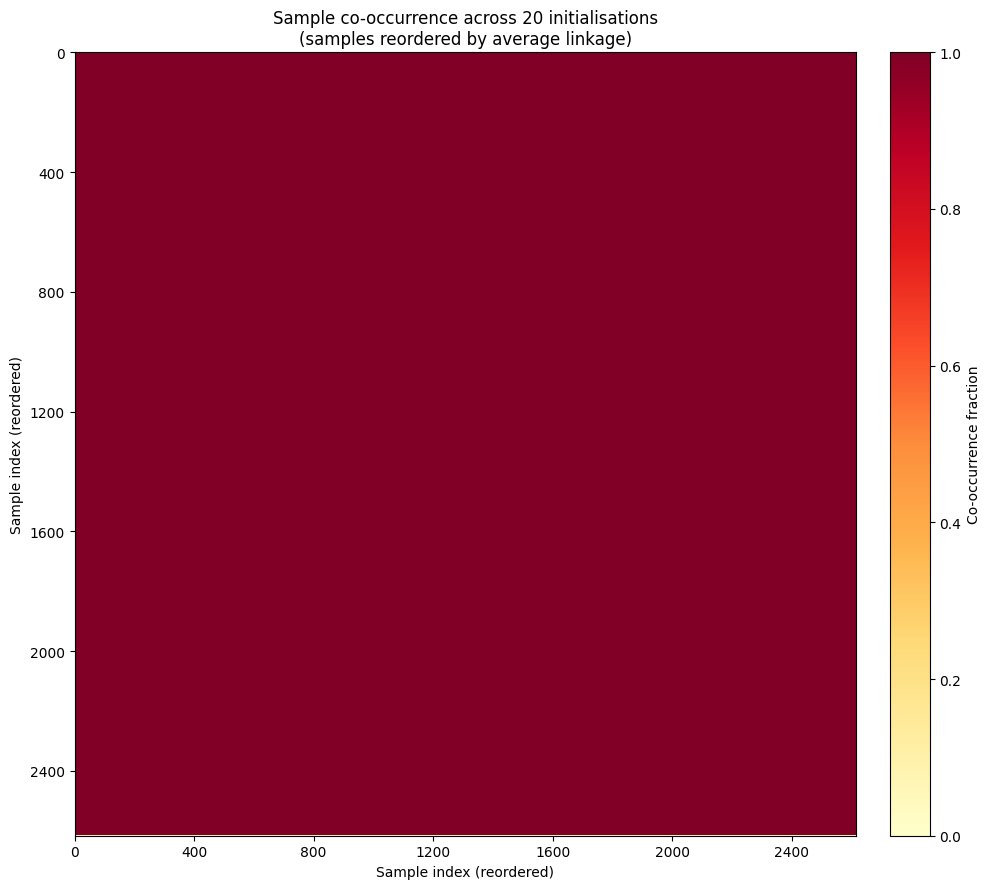

In [3]:
print("Computing linkage for reordering...")
dist_matrix = 1.0 - cooc
# squareform expects condensed distance; clip small negatives from floating point
dist_condensed = squareform(np.clip(dist_matrix, 0.0, None), checks=False)
Z_link = linkage(dist_condensed, method=LINKAGE_METHOD)
order  = leaves_list(Z_link)

cooc_ordered = cooc[np.ix_(order, order)]

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(cooc_ordered, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1,
               interpolation="none")
plt.colorbar(im, ax=ax, label="Co-occurrence fraction", fraction=0.046, pad=0.04)
ax.set_title(
    f"Sample co-occurrence across {n_runs} initialisations\n"
    f"(samples reordered by {LINKAGE_METHOD} linkage)"
)
ax.set_xlabel("Sample index (reordered)")
ax.set_ylabel("Sample index (reordered)")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=8))
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=8))
plt.tight_layout()
plt.show()

In [11]:
np.max(dist_matrix)

np.float64(1.0)

## 4. Dendrogram from Co-occurrence

The dendrogram is derived from the distance matrix $D = 1 - C$ using the same linkage computed above.  
Leaf labels are truncated for readability when $N$ is large.

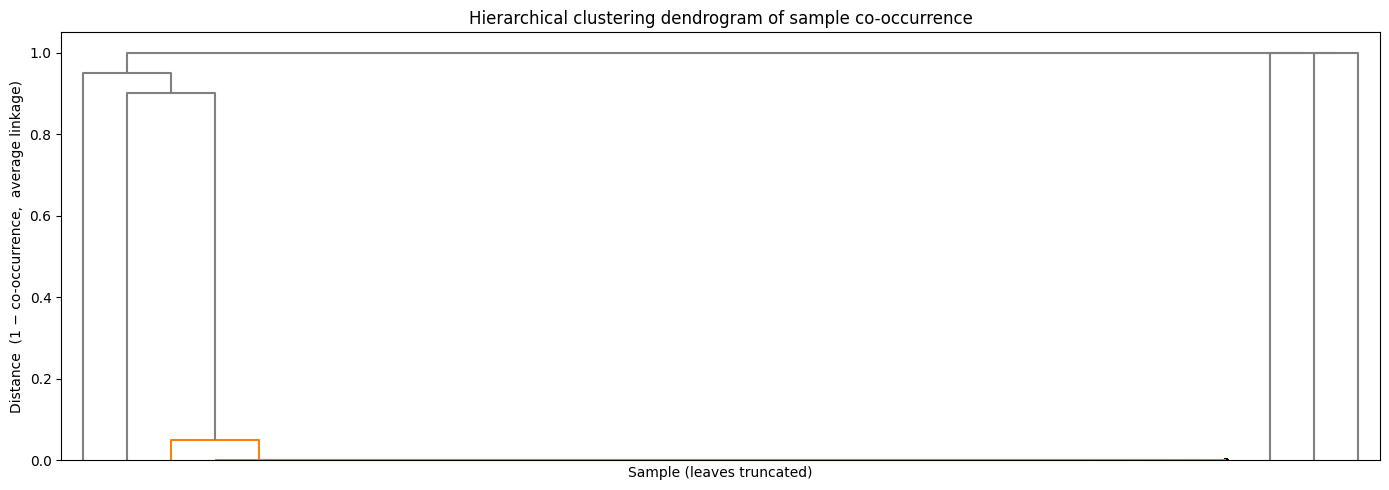

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))

# Truncate to the top p merged nodes when N is large to keep it readable
truncate_p = 30 if N > 200 else None
dend_kwargs = dict(
    Z=Z_link,
    ax=ax,
    color_threshold=0.7 * max(Z_link[:, 2]),
    above_threshold_color="grey",
    no_labels=(N > 200),
)
if truncate_p is not None:
    dend_kwargs["truncate_mode"] = "lastp"
    dend_kwargs["p"] = truncate_p
    dend_kwargs["show_contracted"] = True

dendrogram(**dend_kwargs)

ax.set_xlabel("Sample" + (" (leaves truncated)" if truncate_p else ""))
ax.set_ylabel(f"Distance  (1 − co-occurrence,  {LINKAGE_METHOD} linkage)")
ax.set_title("Hierarchical clustering dendrogram of sample co-occurrence")
plt.tight_layout()
plt.show()

## 5. Spectral Clustering on Co-occurrence Matrix

The co-occurrence matrix $C$ is used directly as the affinity matrix for spectral clustering.  
We sweep over $K \in [2, 15]$ and record the cluster label arrays for silhouette scoring.

In [5]:
spectral_labels = {}   # K → (N,) label array

print(f"Fitting spectral clustering for K in {list(K_RANGE)}...")
for k in K_RANGE:
    sc = SpectralClustering(
        n_clusters=k,
        affinity="precomputed",
        assign_labels="kmeans",
        random_state=42,
        n_init=10,
    )
    labels = sc.fit_predict(cooc)
    spectral_labels[k] = labels
    print(f"  K={k:2d}  unique labels: {np.unique(labels)}")

print("Done.")

Fitting spectral clustering for K in [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]...


c:\Users\jonanord\OneDrive - Universitetet i Oslo\Documents\Code\TiedBayesMallows\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


  K= 2  unique labels: [0 1]


c:\Users\jonanord\OneDrive - Universitetet i Oslo\Documents\Code\TiedBayesMallows\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


  K= 3  unique labels: [0 1 2]


...

  K=13  unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12]


c:\Users\jonanord\OneDrive - Universitetet i Oslo\Documents\Code\TiedBayesMallows\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


  K=14  unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13]


c:\Users\jonanord\OneDrive - Universitetet i Oslo\Documents\Code\TiedBayesMallows\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


  K=15  unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Done.


## 6. Silhouette Scores Across Cluster Counts

The silhouette score is computed using the precomputed distance matrix $D = 1 - C$, so no further feature assumptions are made.  
The optimal K (highest silhouette) is marked with a dashed vertical line.

Computing silhouette scores...
  K= 2  silhouette = 0.9968
  K= 3  silhouette = 0.9970
  K= 4  silhouette = 0.9974
  K= 5  silhouette = 0.9980
  K= 6  silhouette = 0.9980
  K= 7  silhouette = -0.9442
  K= 8  silhouette = -0.9102
  K= 9  silhouette = -0.7073
  K=10  silhouette = -0.6603
  K=11  silhouette = -0.6232
  K=12  silhouette = -0.9587
  K=13  silhouette = -0.6901
  K=14  silhouette = -0.6718
  K=15  silhouette = -0.9343

Best K by silhouette: 6  (score = 0.9980)


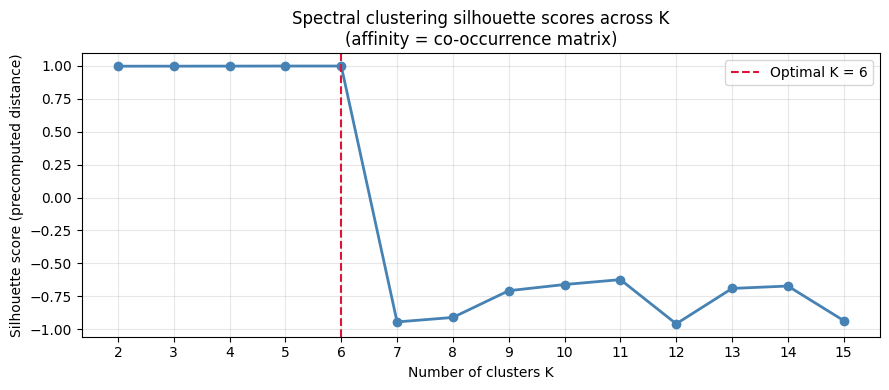

In [6]:
sil_scores = {}
print("Computing silhouette scores...")
for k, labels in spectral_labels.items():
    score = silhouette_score(dist_matrix, labels, metric="precomputed")
    sil_scores[k] = score
    print(f"  K={k:2d}  silhouette = {score:.4f}")

k_values = list(sil_scores.keys())
scores   = list(sil_scores.values())
best_k   = k_values[int(np.argmax(scores))]
print(f"\nBest K by silhouette: {best_k}  (score = {sil_scores[best_k]:.4f})")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_values, scores, marker="o", linewidth=2, color="steelblue")
ax.axvline(best_k, color="crimson", linestyle="--", linewidth=1.5,
           label=f"Optimal K = {best_k}")
ax.set_xlabel("Number of clusters K")
ax.set_ylabel("Silhouette score (precomputed distance)")
ax.set_title("Spectral clustering silhouette scores across K\n(affinity = co-occurrence matrix)")
ax.set_xticks(k_values)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Heatmap Annotated with Optimal Spectral Clustering

The co-occurrence heatmap reordered by the optimal spectral clustering ($K^* = $ `best_k`), with coloured row/column annotation strips showing cluster membership and cancer type.

NameError: name 'mpatches' is not defined

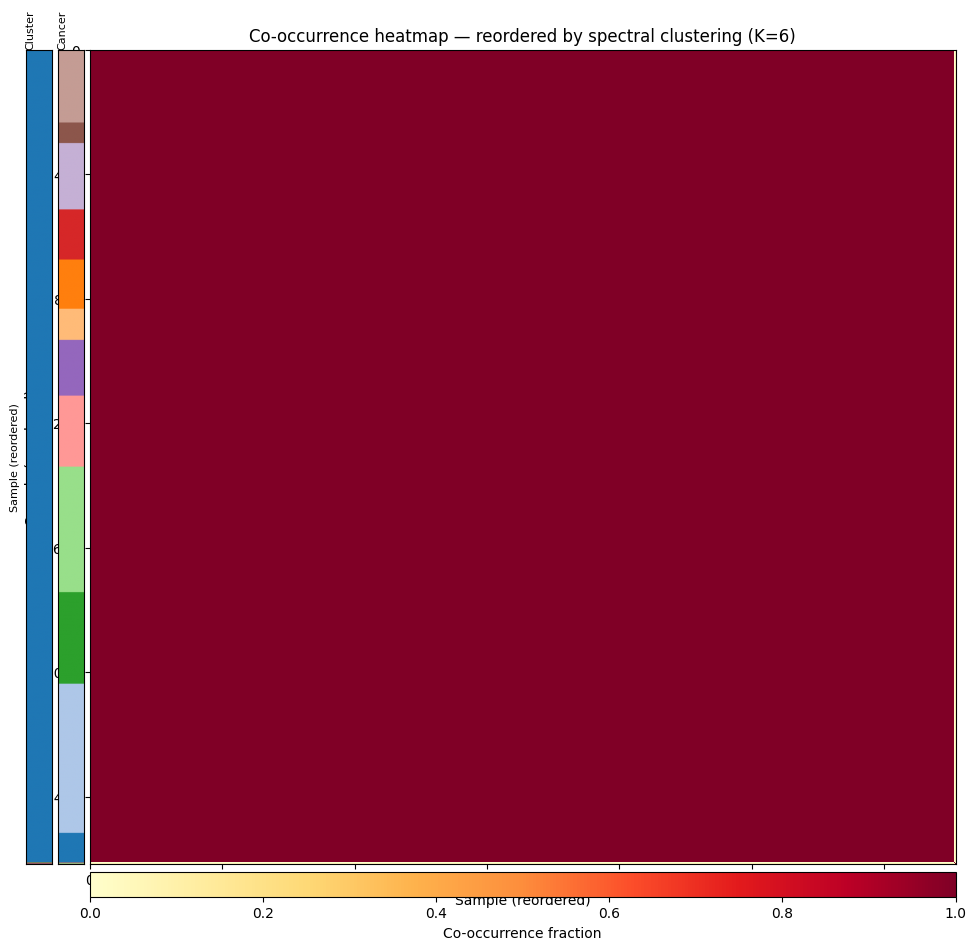

In [8]:
best_labels = spectral_labels[best_k]

# Reorder by spectral cluster label (within each cluster, keep linkage order)
# Build a sort key: primary = spectral label, secondary = linkage order position
linkage_pos = np.argsort(order)   # inverse of leaves_list: sample → rank in dendrogram
sort_key = best_labels * N + linkage_pos
final_order = np.argsort(sort_key)

cooc_final = cooc[np.ix_(final_order, final_order)]
labels_final  = best_labels[final_order]
cancer_final  = cancer_types[final_order]

# Build colour strips
palette_k  = sns.color_palette("tab10", best_k)
palette_ct = sns.color_palette("tab20", len(np.unique(cancer_types)))
ct_list    = sorted(np.unique(cancer_types))

strip_cluster = np.array([palette_k[l] for l in labels_final])            # (N, 3)
strip_cancer  = np.array([palette_ct[ct_list.index(c)] for c in cancer_final])

# --- Figure ---
fig = plt.figure(figsize=(12, 11))
gs = fig.add_gridspec(
    2, 3,
    width_ratios=[0.03, 0.03, 1],
    height_ratios=[1, 0.03],
    hspace=0.02, wspace=0.02,
)

ax_main   = fig.add_subplot(gs[0, 2])
ax_cstrip = fig.add_subplot(gs[0, 0])   # spectral cluster strip (left)
ax_tstrip = fig.add_subplot(gs[0, 1])   # cancer-type strip (left)
ax_cbar   = fig.add_subplot(gs[1, 2])   # colorbar (bottom)

# Heatmap
im = ax_main.imshow(cooc_final, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1,
                    interpolation="none")
ax_main.set_xlabel("Sample (reordered)")
ax_main.set_ylabel("Sample (reordered)")
ax_main.set_title(
    f"Co-occurrence heatmap — reordered by spectral clustering (K={best_k})"
)
ax_main.xaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=8))
ax_main.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=8))

# Left strip: spectral cluster
ax_cstrip.imshow(strip_cluster[:, np.newaxis, :], aspect="auto")
ax_cstrip.set_xticks([])
ax_cstrip.set_yticks([])
ax_cstrip.set_ylabel("Sample (reordered)", fontsize=8)
ax_cstrip.set_title("Cluster", fontsize=8, rotation=90, loc="left", pad=2)

# Left strip: cancer type
ax_tstrip.imshow(strip_cancer[:, np.newaxis, :], aspect="auto")
ax_tstrip.set_xticks([])
ax_tstrip.set_yticks([])
ax_tstrip.set_title("Cancer", fontsize=8, rotation=90, loc="left", pad=2)

# Colorbar
plt.colorbar(im, cax=ax_cbar, orientation="horizontal", label="Co-occurrence fraction")

# Legends
cluster_patches = [
    mpatches.Patch(color=palette_k[k], label=f"Cluster {k}")
    for k in range(best_k)
]
ct_patches = [
    mpatches.Patch(color=palette_ct[i], label=t)
    for i, t in enumerate(ct_list)
]
fig.legend(handles=cluster_patches, title="Spectral cluster",
           loc="upper left", bbox_to_anchor=(0.01, 0.99), fontsize=7, ncol=2)
fig.legend(handles=ct_patches, title="Cancer type",
           loc="lower left", bbox_to_anchor=(0.01, 0.01), fontsize=6, ncol=2)

import matplotlib.patches as mpatches   # ensure available in cell scope
plt.suptitle(
    f"Pan-cancer co-occurrence — optimal spectral clustering K={best_k}  "
    f"(silhouette={sil_scores[best_k]:.3f})",
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.show()